# Estimation and Confidence Intervals

**Module 3: Basic Statistics** | Lean Six Sigma Data Analytics

---

## Estimation in Everyday Life

Estimation is something you do quite often:
- What budget should you save for vacation?
- How long will it take to get to work in rush hour?
- Do you have enough gas to get home?

You don't know the exact answer, but you can make an **educated guess**.

**Key Questions:**
- How do we estimate unknown population values from a sample?
- How precise is our estimate?

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)
print('Data loaded successfully!')

Data loaded successfully!


---

## The Coffee Example

We're interested in the caffeine percentage of **all produced coffee** (population).

We collected a **sample of 40 batches** and measured their caffeine percentage.

**The Question:** How does our sample mean relate to all produced coffee?

In [2]:
# Load Caffeine batches data
caffeine = pd.read_excel(xlsx, sheet_name='Caffeine_batches', skiprows=6, usecols=[0, 1])
caffeine.columns = ['Batch', 'Caffeine_Pct']
caffeine = caffeine.dropna()
caffeine['Caffeine_Pct'] = pd.to_numeric(caffeine['Caffeine_Pct'], errors='coerce')
caffeine = caffeine.dropna()

print(f'Sample size: {len(caffeine)} batches')
print(f'Sample mean: {caffeine["Caffeine_Pct"].mean():.4f}')
caffeine.head()

Sample size: 40 batches
Sample mean: 0.0832


,Batch,Caffeine_Pct
0,082002-C116,0.092
1,082002-C122,0.105
2,082002-C126,0.079
3,082002-C141,0.118
4,082002-C147,0.069


---

## Sample Statistics vs Population Parameters

| Concept | Sample (Known) | Population (Unknown) |
|---------|----------------|----------------------|
| Location | Mean (x̄) or Median | μ (mu) |
| Spread | Std Dev (s) or IQR | σ (sigma) |
| Symbol | Latin letters | Greek letters |

We use **sample statistics** to **estimate** population parameters.

```
Sample Statistics  ────►  Estimate  ────►  Population Parameters
     x̄, s                                        μ, σ
   (known)                                     (unknown)
```

---

## Graphical Summary

Minitab: **Stat > Basic Statistics > Graphical Summary**

This combines histogram, boxplot, statistics, and confidence intervals.

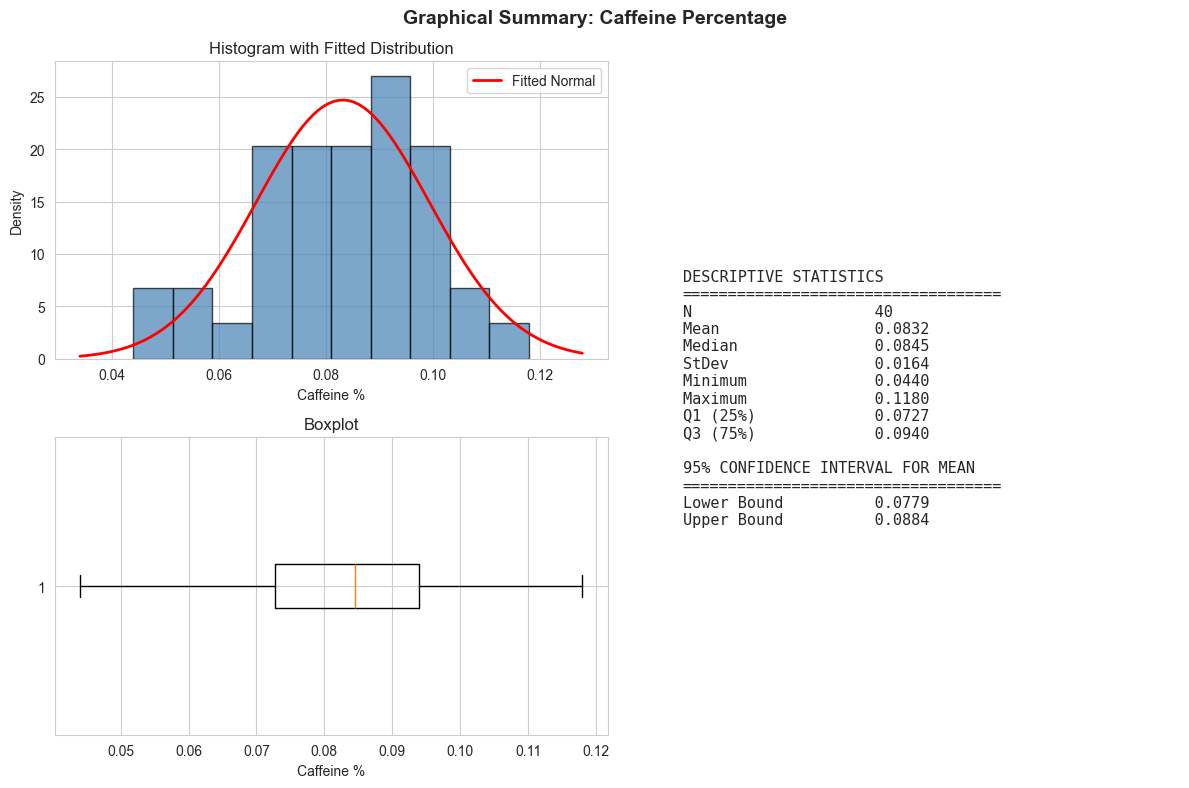

In [3]:
# Graphical Summary - equivalent to Minitab: Stat > Basic Statistics > Graphical Summary
data = caffeine['Caffeine_Pct']

fig = plt.figure(figsize=(12, 8))

# Histogram with fitted normal distribution
ax1 = fig.add_subplot(2, 2, 1)
ax1.hist(data, bins=10, density=True, alpha=0.7, color='steelblue', edgecolor='black')
# Fit and plot normal distribution
mu_fit, sigma_fit = stats.norm.fit(data)
x_range = np.linspace(data.min() - 0.01, data.max() + 0.01, 100)
ax1.plot(x_range, stats.norm.pdf(x_range, mu_fit, sigma_fit), 'r-', lw=2, label='Fitted Normal')
ax1.set_xlabel('Caffeine %')
ax1.set_ylabel('Density')
ax1.set_title('Histogram with Fitted Distribution')
ax1.legend()

# Boxplot
ax2 = fig.add_subplot(2, 2, 3)
ax2.boxplot(data, vert=False)
ax2.set_xlabel('Caffeine %')
ax2.set_title('Boxplot')

# Statistics table
ax3 = fig.add_subplot(1, 2, 2)
ax3.axis('off')

# Calculate statistics
n = len(data)
mean = data.mean()
median = data.median()
std = data.std()
sem = stats.sem(data)  # Standard error of mean
ci_95 = stats.t.interval(0.95, df=n-1, loc=mean, scale=sem)

stats_text = f"""
DESCRIPTIVE STATISTICS
{'='*35}
N                    {n}
Mean                 {mean:.4f}
Median               {median:.4f}
StDev                {std:.4f}
Minimum              {data.min():.4f}
Maximum              {data.max():.4f}
Q1 (25%)             {data.quantile(0.25):.4f}
Q3 (75%)             {data.quantile(0.75):.4f}

95% CONFIDENCE INTERVAL FOR MEAN
{'='*35}
Lower Bound          {ci_95[0]:.4f}
Upper Bound          {ci_95[1]:.4f}
"""
ax3.text(0.1, 0.5, stats_text, fontsize=11, family='monospace', 
         verticalalignment='center', transform=ax3.transAxes)

plt.suptitle('Graphical Summary: Caffeine Percentage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Understanding the Fitted Distribution

- **Blue bars:** Histogram of our 40 sample values
- **Red line:** Estimated (fitted) population distribution

The red line represents **all coffee produced**, not just our sample.

We want to know:
- **Location (μ):** Where is the center? (Unknown—we haven't measured all coffee)
- **Spread (σ):** How much variation? (Also unknown)

---

## Which Estimator to Use?

### For Location (μ)

| Estimator | Pros | Cons |
|-----------|------|------|
| **Mean** | More precise (uses all data) | Sensitive to outliers |
| **Median** | Robust to outliers | Less precise |

### For Spread (σ)

| Estimator | Pros | Cons |
|-----------|------|------|
| **Std Dev** | Most precise (uses all data) | Sensitive to outliers |
| **IQR** | Robust to outliers | Less precise |
| **Range** | Simple to calculate | Very sensitive to outliers |

**Which one?** It depends on the situation!

In [4]:
# Compare estimators
print('ESTIMATORS FOR LOCATION (μ)')
print('=' * 40)
print(f'  Mean:   {data.mean():.4f}  (precise, uses all data)')
print(f'  Median: {data.median():.4f}  (robust to outliers)')

print('\nESTIMATORS FOR SPREAD (σ)')
print('=' * 40)
print(f'  Std Dev: {data.std():.4f}  (precise, uses all data)')
print(f'  IQR:     {data.quantile(0.75) - data.quantile(0.25):.4f}  (robust to outliers)')
print(f'  Range:   {data.max() - data.min():.4f}  (simple but sensitive)')

ESTIMATORS FOR LOCATION (μ)
  Mean:   0.0832  (precise, uses all data)
  Median: 0.0845  (robust to outliers)

ESTIMATORS FOR SPREAD (σ)
  Std Dev: 0.0164  (precise, uses all data)
  IQR:     0.0213  (robust to outliers)
  Range:   0.0740  (simple but sensitive)


---

## Confidence Intervals

Our estimates are based on only 40 measurements—not a large sample.

**How precise are these estimates?**

Statistics is about making inference **under uncertainty**. To quantify this uncertainty, we calculate **confidence intervals**.

### Definition

A **confidence interval** gives boundaries within which a population parameter will lie with a certain level of confidence.

The most common confidence level is **95%**.

In [7]:
# Calculate confidence intervals
n = len(data)
mean = data.mean()
sem = stats.sem(data)  # Standard error of the mean

# 95% CI for the mean
ci_95 = stats.t.interval(0.95, df=n-1, loc=mean, scale=sem)

# 90% and 99% for comparison
ci_90 = stats.t.interval(0.90, df=n-1, loc=mean, scale=sem)
ci_99 = stats.t.interval(0.99, df=n-1, loc=mean, scale=sem)

print('CONFIDENCE INTERVALS FOR POPULATION MEAN (μ)')
print('=' * 50)
print(f'Sample Mean: {mean:.4f}')
print(f'Sample Size: {n}')
print()
print(f'90% CI: ({ci_90[0]:.4f}, {ci_90[1]:.4f})  Width: {ci_90[1]-ci_90[0]:.4f}')
print(f'95% CI: ({ci_95[0]:.4f}, {ci_95[1]:.4f})  Width: {ci_95[1]-ci_95[0]:.4f}')
print(f'99% CI: ({ci_99[0]:.4f}, {ci_99[1]:.4f})  Width: {ci_99[1]-ci_99[0]:.4f}')

print('\nInterpretation (95% CI):')
print(f'  We are 95% confident that the true population mean')
print(f'  lies between {ci_95[0]:.4f} and {ci_95[1]:.4f}')

CONFIDENCE INTERVALS FOR POPULATION MEAN (μ)
Sample Mean: 0.0832
Sample Size: 40

90% CI: (0.0788, 0.0875)  Width: 0.0087
95% CI: (0.0779, 0.0884)  Width: 0.0105
99% CI: (0.0762, 0.0902)  Width: 0.0140

Interpretation (95% CI):
  We are 95% confident that the true population mean
  lies between 0.0779 and 0.0884


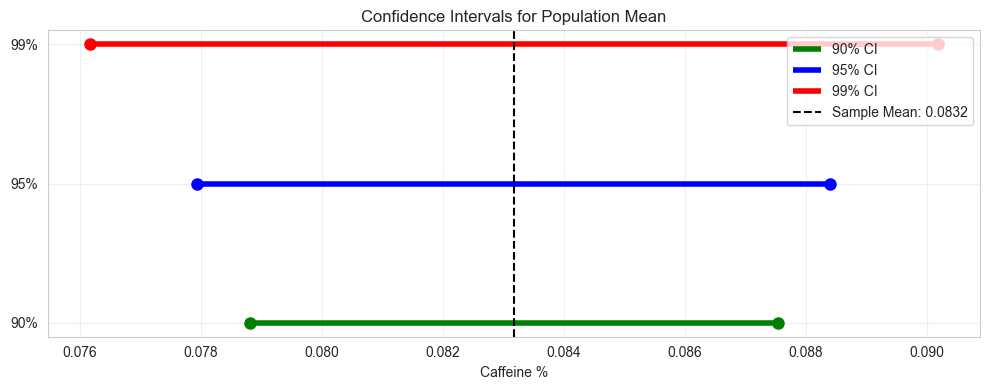

Note: Higher confidence = wider interval
      More certainty requires accepting more uncertainty in the range


In [6]:
# Visualize confidence intervals
plt.figure(figsize=(10, 4))

# Plot the intervals
levels = ['90%', '95%', '99%']
intervals = [ci_90, ci_95, ci_99]
colors = ['green', 'blue', 'red']

for i, (level, ci, color) in enumerate(zip(levels, intervals, colors)):
    plt.hlines(y=i, xmin=ci[0], xmax=ci[1], colors=color, linewidth=4, label=f'{level} CI')
    plt.plot([ci[0], ci[1]], [i, i], 'o', color=color, markersize=8)

plt.axvline(mean, color='black', linestyle='--', label=f'Sample Mean: {mean:.4f}')
plt.yticks([0, 1, 2], levels)
plt.xlabel('Caffeine %')
plt.title('Confidence Intervals for Population Mean')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Note: Higher confidence = wider interval')
print('      More certainty requires accepting more uncertainty in the range')

---

## Effect of Sample Size

Larger samples give more precise estimates → **narrower confidence intervals**.

In [8]:
# Demonstrate effect of sample size on CI width
# Using our actual sample statistics, show how CI would change with different n
sample_sizes = [10, 20, 40, 100, 200]
sample_std = data.std()
sample_mean = data.mean()

print('EFFECT OF SAMPLE SIZE ON 95% CI WIDTH')
print('=' * 50)
print(f'(Assuming same mean={sample_mean:.4f} and std={sample_std:.4f})')
print()

for n in sample_sizes:
    sem = sample_std / np.sqrt(n)
    ci = stats.t.interval(0.95, df=n-1, loc=sample_mean, scale=sem)
    width = ci[1] - ci[0]
    print(f'  n={n:3d}: CI width = {width:.4f}  ({ci[0]:.4f}, {ci[1]:.4f})')

print('\nConclusion: Larger sample → Narrower CI → More precise estimate')

EFFECT OF SAMPLE SIZE ON 95% CI WIDTH
(Assuming same mean=0.0832 and std=0.0164)

  n= 10: CI width = 0.0234  (0.0715, 0.0949)
  n= 20: CI width = 0.0153  (0.0755, 0.0908)
  n= 40: CI width = 0.0105  (0.0779, 0.0884)
  n=100: CI width = 0.0065  (0.0799, 0.0864)
  n=200: CI width = 0.0046  (0.0809, 0.0855)

Conclusion: Larger sample → Narrower CI → More precise estimate


---

## Summary

| Concept | Description |
|---------|-------------|
| **Estimation** | Using sample statistics to approximate unknown population parameters |
| **Sample → Population** | x̄ estimates μ, s estimates σ |
| **Confidence Interval** | Boundaries where population parameter lies with certain confidence |
| **95% CI** | Most commonly used confidence level |
| **Sample Size** | Larger samples → narrower CIs → more precise estimates |

---

## Key Takeaways

- **Estimates** are educated guesses about unknown population parameters
- Estimates are **never exactly equal** to population parameters (based on sample)
- **Confidence intervals** quantify uncertainty around estimates
- **95% CI interpretation:** "We are 95% confident the true value lies in this range"
- **Larger samples** give more precise estimates (narrower intervals)
- Choose estimators based on situation: mean vs median, std dev vs IQR